In [1]:
import jax
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax.numpy as jnp
wanted_type_complex = jnp.complex128
wanted_type_real = jnp.float64
print("Devices:", jax.devices())
if not any(d.platform == "gpu" for d in jax.devices()):
    raise RuntimeError("JAX is not using a GPU.")
import sys
sys.path.insert(0, "/home/tmalasda/dev")
from cheb_ar import ChebAr
import numpy as np
import dynamiqs as dq
from scipy.special import jv
import matplotlib.pyplot as plt

Devices: [CudaDevice(id=0)]


In [ ]:
n_a = 20
n_b = 8
alpha_sq = 6
eps_p = .1
eps_p_init = .1
kappa_b_init = .6 / 10.4 *5
E_J=37 * 2 * np.pi
phi_a=0.11
phi_b=0.204
g = np.sin(eps_p_init) * E_J * phi_a**2 * phi_b
print(kappa_b_init / g)

5.035178264225644


# Warm start

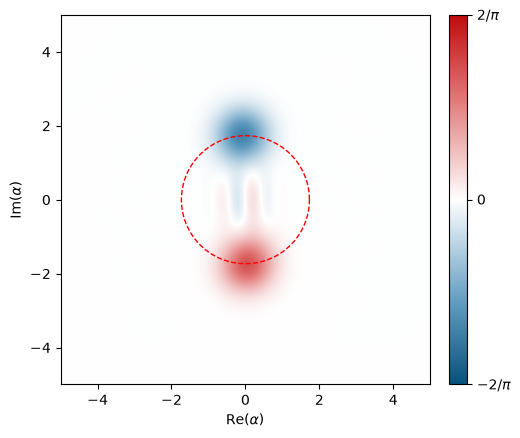

In [3]:
import json
def _from_jsonable(obj):
    """Recursively convert JSON types back to numpy/complex objects.
    
    ``{"real": ..., "imag": ...}`` dicts become complex numbers;
    lists become numpy arrays if they contain numeric/complex values.
    """
    if isinstance(obj, dict):
        # Complex number encoding
        if set(obj.keys()) == {"real", "imag"}:
            return complex(obj["real"], obj["imag"])
        # Regular dict: recurse on values
        return {k: _from_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        converted = [_from_jsonable(v) for v in obj]
        # Convert to numpy array if all elements are numeric or complex
        if all(isinstance(v, (int, float, complex, np.ndarray)) for v in converted):
            return np.array(converted)
        return converted
    return obj  # int, float, str → keep as-is


def load_json(path):
    """Load a JSON file and return a dict with numpy/complex values."""
    with open(path, "r") as f:
        raw = json.load(f)
    return _from_jsonable(raw)

data = load_json("/home/tmalasda/output/Cheb_Ar/13_07_2026/cheb_ar_vs_epsp_alphasq_6.json")[0]
x_ritz_warm  = data["x_ritz"]

rho_ritz_warm = dq.unvectorize(dq.asqarray(x_ritz_warm[:, None]))
rho_ritz_warm = dq.asqarray(dq.to_jax(rho_ritz_warm), dims=(n_a, n_b))
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz_warm,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

# Cheb-Ar

In [4]:
def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

In [5]:
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b_init)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)


In [6]:
params['g2']/2/np.pi*1e3

np.float64(4.560834202910811)

In [7]:
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)

In [8]:
x0 = solver.make_x0(seed=0)
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)

|██████████| 100.0% ◆ elapsed 501.36ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 462.32ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 589.06ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 431.26ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 420.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 416.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 403.66ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 401.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 405.37ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 398.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 393.61ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 391.94ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 393.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 393.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 389.45ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.25ms ◆

In [9]:
solver.setup_chebyshev(ritz_vals, margin=1e-2)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.29431904379464324-2.2668132519543797e-15j),
 'semi_re': np.float64(0.6588975186944049),
 'semi_im': np.complex128(0.8233117293151704-4.74973971121739e-16j),
 'ritz_bitflip': np.complex128(0.9632165624890482-2.9178104897983296e-15j),
 'vertex_x': np.complex128(0.9532165624890482-2.9178104897983296e-15j),
 'margin': 0.01,
 'max_level': 0.9900000000000001,
 'ritz_vals_enc': array([-0.1251624 -6.28609954e-01j, -0.12053744-6.28755079e-01j,
        -0.05718866-6.52947091e-01j, -0.04234451-6.66069666e-01j,
         0.00287098-6.76444376e-01j,  0.03083075-6.90536210e-01j,
         0.08047341-6.63081406e-01j,  0.1413844 -7.40975489e-01j,
         0.18781988-8.08303865e-01j,  0.19121452-6.76083373e-01j,
         0.23561754-7.82443481e-01j,  0.27154175-7.86007939e-01j,
         0.31757632-7.59108798e-01j,  0.37365919-7.82590885e-01j,
         0.41987027-7.30843455e-01j,  0.50891524-6.87886535e-01j,
         0.44955693-6.54113058e-01j,  0.56060292-6.46509514e-01j,
    

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


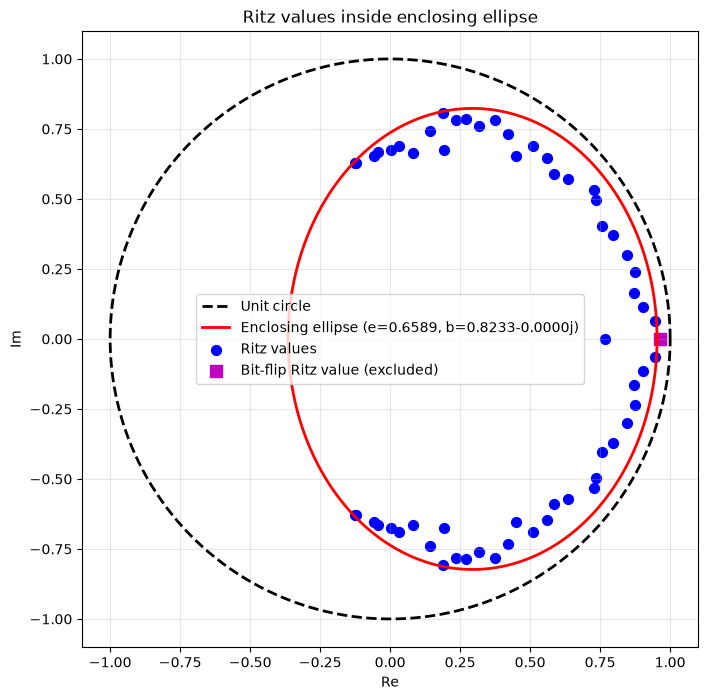

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [11]:
m_arnoldi = 100
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi)

|██████████| 100.0% ◆ elapsed 484.94ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 455.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 537.73ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 613.44ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 677.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 725.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 397.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 422.01ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 503.68ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 580.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 650.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 698.94ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 369.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 390.82ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 471.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 547.91ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 617.88ms ◆

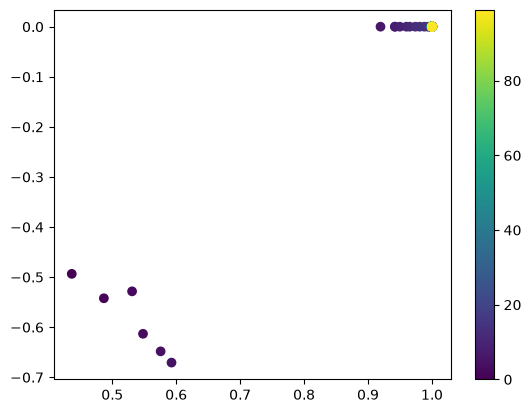

In [12]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

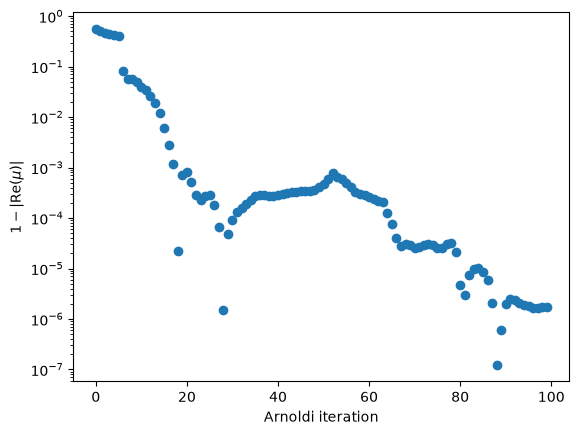

In [13]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [14]:
solver.rate_from_mu(mu_list[-1])

Array(6.85619056e-06+2.00740486e-15j, dtype=complex128)

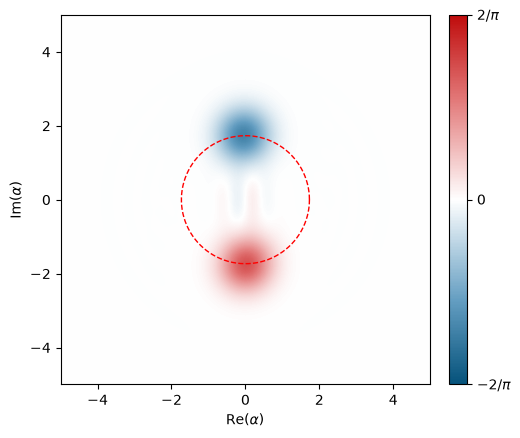

In [15]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [16]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 158.51ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99999829-8.13609027e-17j, dtype=complex128),
 'res_rel': Array(6.20550119e-06, dtype=float64),
 'rate_RQ': Array(6.90656545e-06+3.28112121e-16j, dtype=complex128)}

In [17]:
eps_p = .1
kappa_b_init = .6/10.4
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b_init)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 154.17ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 183.53ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 231.85ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 296.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 296.49ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 369.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 400.00ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 382.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 435.12ms ◆ remaining 0.0

In [18]:
solver.setup_chebyshev(ritz_vals, margin=1e-5)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.242099338967257+8.147562498506907e-16j),
 'semi_re': np.float64(0.7578725971743409),
 'semi_im': np.complex128(1.0280880532010896+7.343401419508957e-16j),
 'ritz_bitflip': np.complex128(0.9999819361415978+1.0901591321630058e-15j),
 'vertex_x': np.complex128(0.9999719361415979+1.0901591321630058e-15j),
 'margin': 1e-05,
 'max_level': 0.9999900000000002,
 'ritz_vals_enc': array([-0.13606259-8.90950102e-01j, -0.12922961-8.91643404e-01j,
        -0.04787206-9.17061380e-01j, -0.05166961-9.05191979e-01j,
        -0.02412604-9.13055136e-01j,  0.0372017 -9.32380760e-01j,
         0.03112261-9.13778953e-01j,  0.10935778-9.32902313e-01j,
         0.11944995-9.27773930e-01j,  0.18819207-9.30377544e-01j,
         0.23504784-9.13613718e-01j,  0.27848574-8.97368863e-01j,
         0.3379165 -8.83728510e-01j,  0.39099984-8.55099367e-01j,
         0.44113942-8.25345542e-01j,  0.4948492 -7.94509738e-01j,
         0.55024933-7.60984474e-01j,  0.61297027-7.13640355e-01j,
     

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


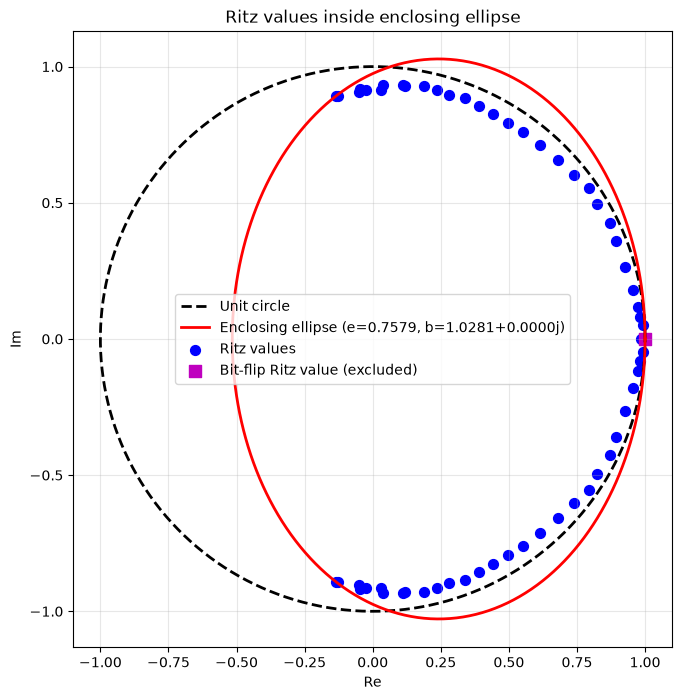

In [19]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [20]:
m_arnoldi = 100
x0 = x_ritz
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 154.87ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 154.32ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 160.57ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 184.51ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 210.41ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 235.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 170.14ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 176.30ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 219.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 255.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 298.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 349.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 208.33ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 214.00ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 260.13ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 297.39ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 353.94ms ◆ remai

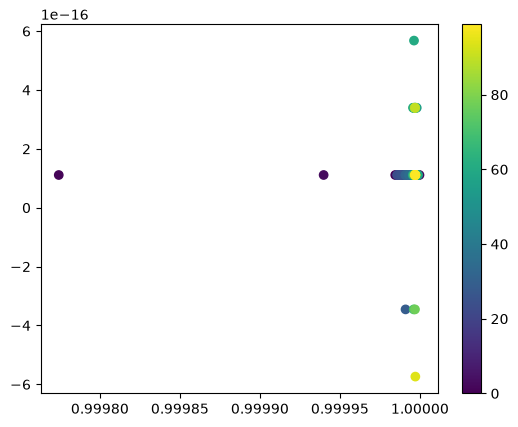

In [25]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

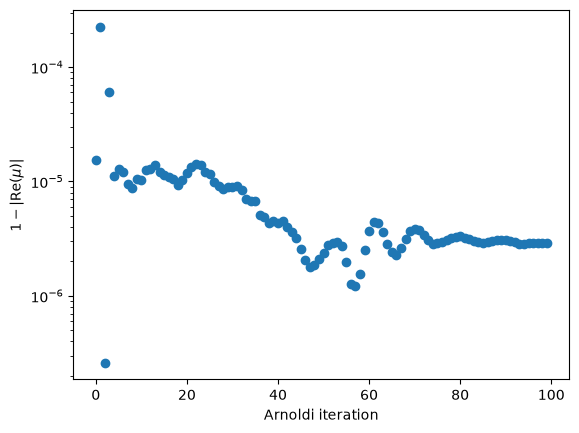

In [26]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [27]:
solver.rate_from_mu(mu_list[-1])

Array(1.177594e-05-4.48317304e-16j, dtype=complex128)

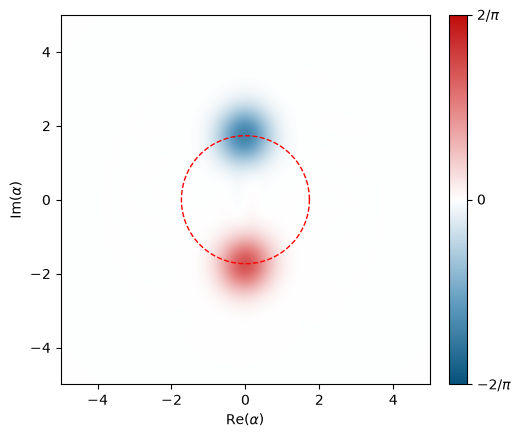

In [28]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [29]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 167.49ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99999707-9.8970625e-17j, dtype=complex128),
 'res_rel': Array(5.73236946e-06, dtype=float64),
 'rate_RQ': Array(1.18093976e-05+3.99129067e-16j, dtype=complex128)}

In [30]:
eps_p = .1
kappa_b_init = .3/10.4
g = np.sin(eps_p) * E_J * phi_a**2 * phi_b
print(kappa_b_init/g)
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b_init)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


0.5035178264225644


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 167.66ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 243.49ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 285.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 288.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 296.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 372.52ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 424.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 398.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 384.27ms ◆ remaining 0.

In [31]:
solver.setup_chebyshev(ritz_vals, margin=1e-5)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.24059643799413344-4.428195379602383e-16j),
 'semi_re': np.float64(0.7593725992130156),
 'semi_im': np.complex128(1.0757919854136557-4.172447309861708e-16j),
 'ritz_bitflip': np.complex128(0.999979037207149-5.928976934913038e-16j),
 'vertex_x': np.complex128(0.999969037207149-5.928976934913038e-16j),
 'margin': 1e-05,
 'max_level': 0.9999899999999999,
 'ritz_vals_enc': array([-0.13855278-9.32095854e-01j, -0.13138646-9.32970667e-01j,
        -0.04965806-9.50813258e-01j, -0.05058557-9.43932575e-01j,
         0.03464761-9.57513737e-01j,  0.03577327-9.51175966e-01j,
         0.0383963 -9.39568818e-01j,  0.1135888 -9.55020079e-01j,
         0.12480171-9.44475032e-01j,  0.19511587-9.45233906e-01j,
         0.2422686 -9.34359333e-01j,  0.29420225-9.17464187e-01j,
         0.34255105-8.99520497e-01j,  0.40469909-8.70885321e-01j,
         0.47436624-8.33356393e-01j,  0.52919938-7.91944633e-01j,
         0.60798324-7.40277339e-01j,  0.68397963-6.97131371e-01j,
       

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


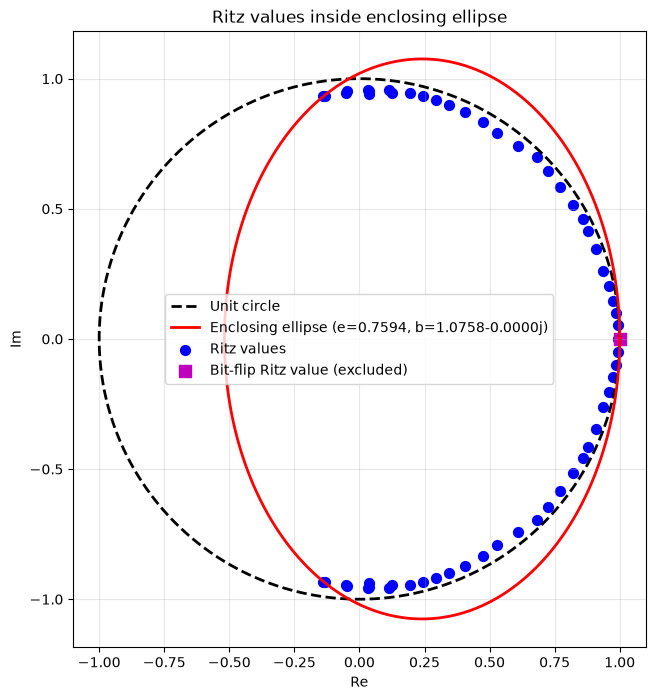

In [32]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [33]:
m_arnoldi = 60
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 164.90ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 157.11ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 173.12ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.48ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 232.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 266.48ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 232.13ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 234.75ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 283.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 298.96ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 369.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 405.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 272.06ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 273.49ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 329.42ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 378.53ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 426.53ms ◆ rem

In [35]:
m_arnoldi_new = 120
Q_new, H_new, mu_list_new = solver.arnoldi_hessenberg(
    x0, 
    solver.chebyshev_filter, 
    m_new = m_arnoldi_new,
    m_old = m_arnoldi,
    Q_old = Q,
    H_old = H,
    mu_list_old = mu_list,
    )

|██████████| 100.0% ◆ elapsed 416.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 410.26ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 478.43ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 528.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 574.12ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 621.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 399.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 407.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 472.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 522.32ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 572.73ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 611.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.70ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 396.40ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 459.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 514.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 561.19ms ◆

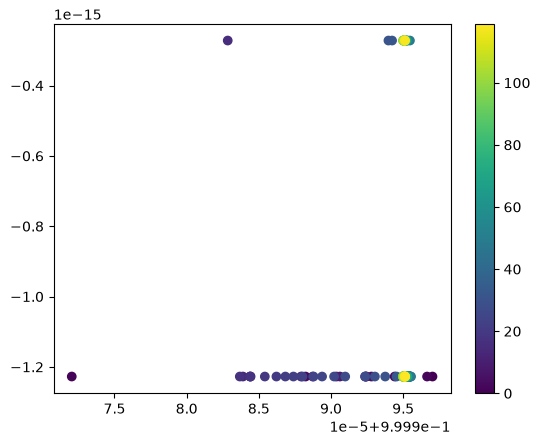

In [36]:
plt.scatter(np.real(mu_list_new), np.imag(mu_list_new), c=range(m_arnoldi_new))
plt.colorbar()
plt.show()

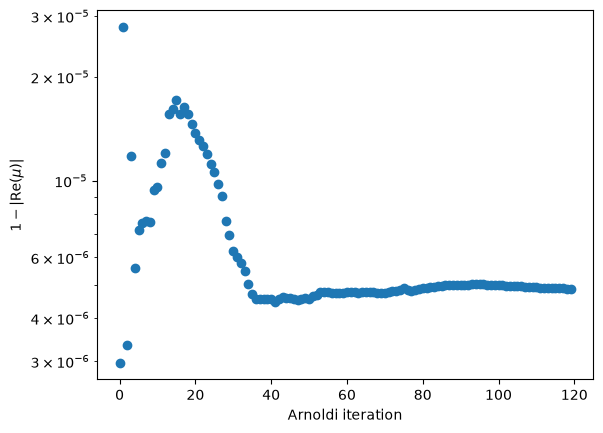

In [37]:
plt.scatter(range(m_arnoldi_new), np.abs(1-np.real(mu_list_new)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [38]:
solver.rate_from_mu(mu_list_new[-1])

Array(1.96154802e-05+4.95011443e-15j, dtype=complex128)

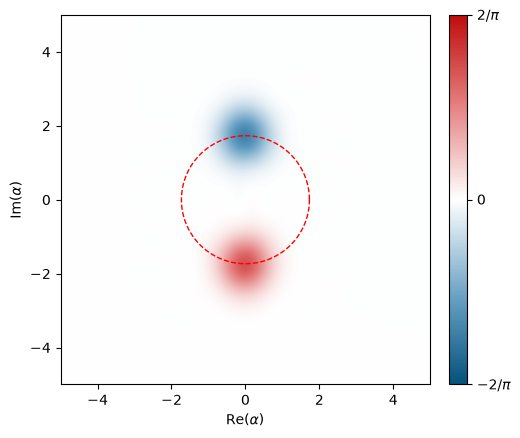

In [39]:
x_ritz, rho_ritz = solver.ritz_vector(Q_new, H_new, m_arnoldi_new, target=mu_list_new[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [40]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 169.22ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99999513-3.52998916e-16j, dtype=complex128),
 'res_rel': Array(5.4664748e-06, dtype=float64),
 'rate_RQ': Array(1.96300083e-05+1.42357797e-15j, dtype=complex128)}

In [41]:
eps_p = .2
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 173.88ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 234.61ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 297.31ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 416.71ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 443.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 453.35ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 464.32ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 470.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 473.69ms ◆ remaining 0.

In [42]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03011951450196415-1.71168413818048e-16j),
 'semi_re': np.float64(0.9648696105824833),
 'semi_im': np.complex128(0.9696746691806394-1.5232748768987905e-17j),
 'ritz_bitflip': np.complex128(0.9999891250844475-2.5252078171385827e-16j),
 'vertex_x': np.complex128(0.9949891250844475-2.5252078171385827e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999999,
 'ritz_vals_enc': array([-0.91885923-1.56027932e-01j, -0.81592407-3.85125212e-01j,
        -0.86426011-2.37305398e-01j, -0.74618593-4.62063416e-01j,
        -0.6916252 -5.40522820e-01j, -0.64085334-5.99143814e-01j,
        -0.5472801 -6.96695536e-01j, -0.3507142 -8.81324777e-01j,
        -0.44057647-7.70091090e-01j, -0.87678712-4.74745640e-02j,
        -0.87678712+4.74745640e-02j, -0.91885923+1.56027932e-01j,
        -0.86426011+2.37305398e-01j, -0.81592407+3.85125212e-01j,
        -0.74618593+4.62063416e-01j, -0.6916252 +5.40522820e-01j,
        -0.64085334+5.99143814e-01j, -0.5472801 +6.96695536e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


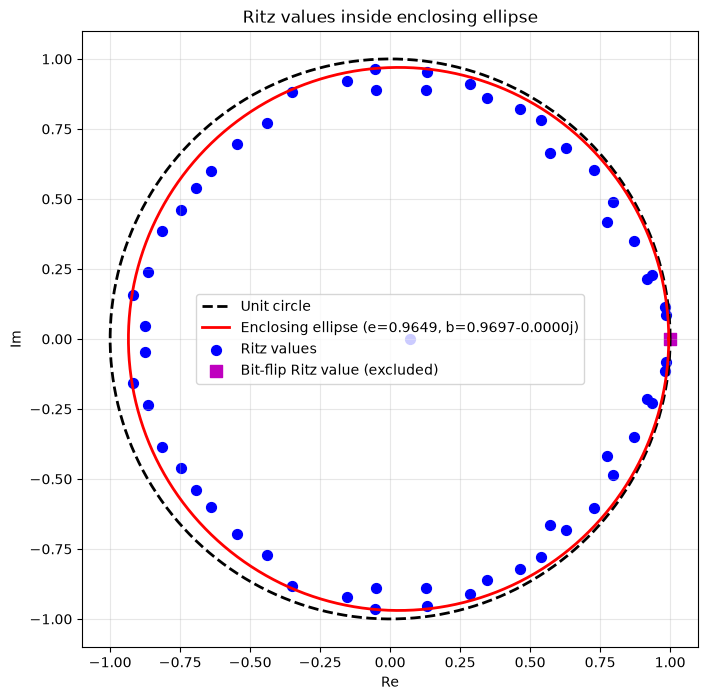

In [43]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [44]:
m_arnoldi = 80
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 146.79ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 221.85ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 350.77ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 486.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 584.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 662.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 211.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 294.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 481.13ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 607.53ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 677.96ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 744.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 239.98ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 371.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 534.87ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 640.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 710.56ms ◆ 

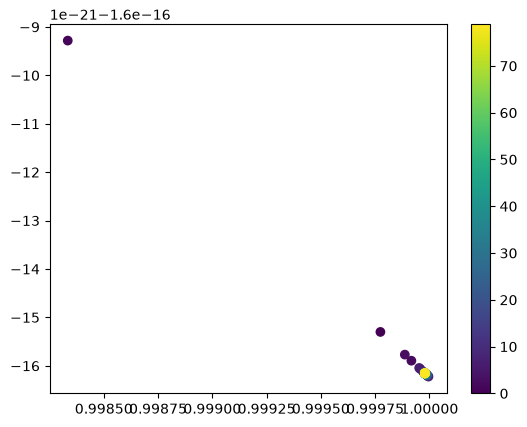

In [45]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

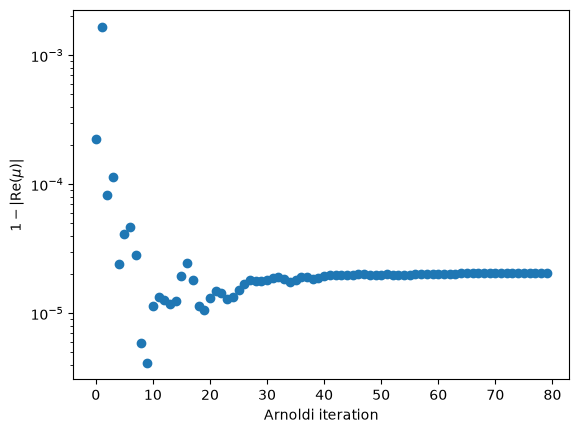

In [47]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [48]:
solver.rate_from_mu(mu_list[-1])

Array(8.30938814e-05+6.45325087e-16j, dtype=complex128)

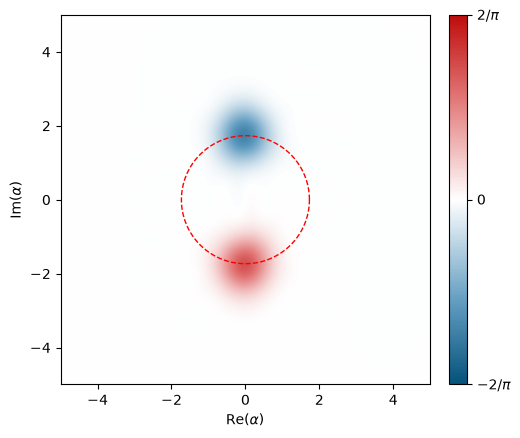

In [49]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [50]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 176.56ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99997939+8.11278856e-16j, dtype=complex128),
 'res_rel': Array(5.33072457e-06, dtype=float64),
 'rate_RQ': Array(8.31119732e-05-3.27178592e-15j, dtype=complex128)}

In [51]:
eps_p = .3
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 183.76ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 260.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 336.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 414.35ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 430.53ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 443.45ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 451.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 452.32ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 450.22ms ◆ remaining 0.

In [52]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03003911040589191-2.137720222734231e-17j),
 'semi_re': np.float64(0.9648313963847932),
 'semi_im': np.complex128(1.0078660295435578+1.6267518847920398e-15j),
 'ritz_bitflip': np.complex128(0.9998705067906851-3.153728948520833e-17j),
 'vertex_x': np.complex128(0.9948705067906851-3.153728948520833e-17j),
 'margin': 0.005,
 'max_level': 0.995,
 'ritz_vals_enc': array([-0.92781465+1.12132525e-14j, -0.85158511-3.47792417e-01j,
        -0.8042483 -4.70043851e-01j, -0.75471747-5.81013392e-01j,
        -0.73093154-5.51688100e-01j, -0.85183472-1.84135953e-01j,
        -0.85183472+1.84135953e-01j, -0.85158511+3.47792417e-01j,
        -0.76494836-4.87099938e-13j, -0.8042483 +4.70043851e-01j,
        -0.75471747+5.81013392e-01j, -0.73093154+5.51688100e-01j,
        -0.62188164+6.89479682e-01j, -0.55655189+7.71446449e-01j,
        -0.48835341+7.58221346e-01j, -0.35747496+8.81806306e-01j,
        -0.28774863+8.57744894e-01j, -0.19602506+9.26046418e-01j,
        -0.082319

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


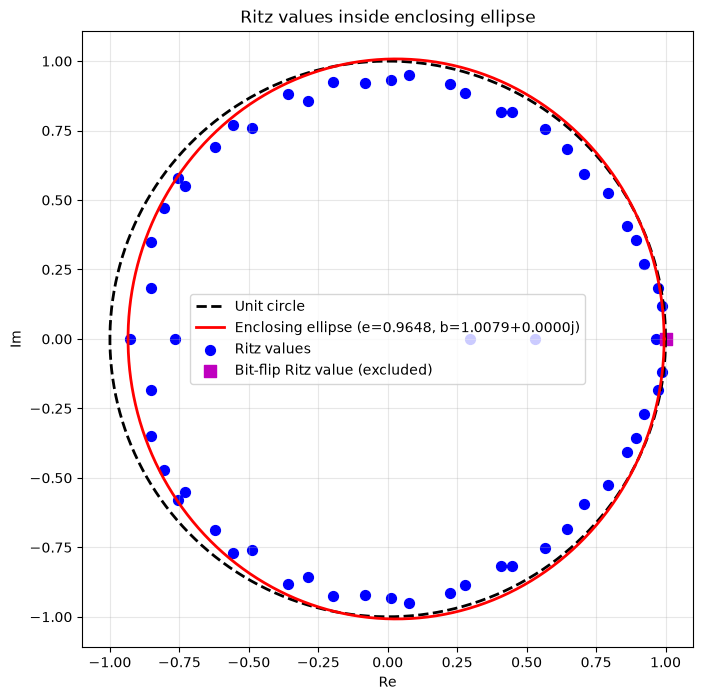

In [53]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [54]:
m_arnoldi = 80
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 155.10ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 193.16ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 273.64ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 366.46ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 465.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 539.05ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 216.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 268.37ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 370.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 477.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 560.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 622.10ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 220.86ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 278.37ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 386.47ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 501.78ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 589.47ms ◆ r

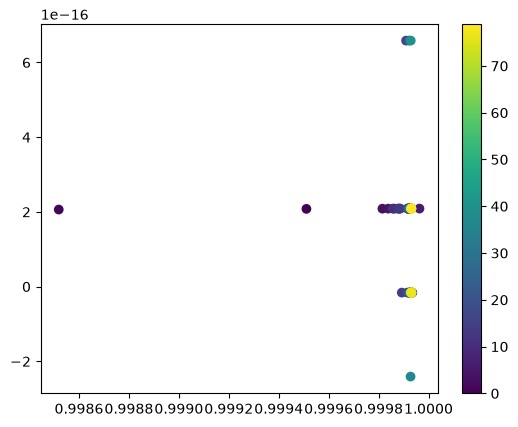

In [56]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

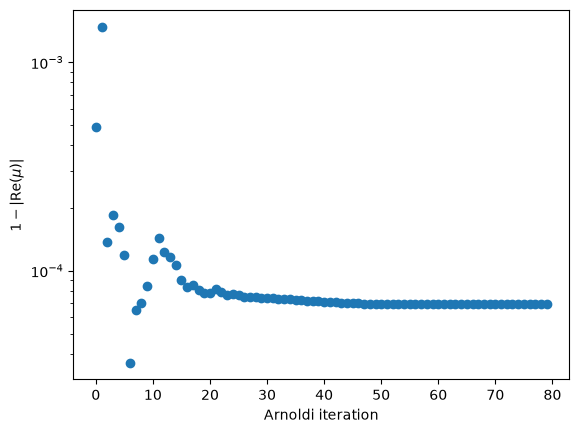

In [57]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [58]:
solver.rate_from_mu(mu_list[-1])

Array(0.0002787-8.4230121e-16j, dtype=complex128)

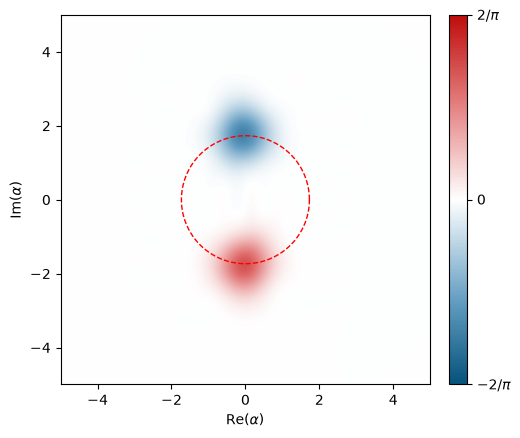

In [59]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [60]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 208.58ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99993089+1.38453462e-16j, dtype=complex128),
 'res_rel': Array(3.58673677e-07, dtype=float64),
 'rate_RQ': Array(0.00027871-5.5839254e-16j, dtype=complex128)}

In [61]:
eps_p = .5
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 210.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 284.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 362.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 415.35ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 412.63ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 411.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 408.21ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 409.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 410.33ms ◆ remaining 0

In [62]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.02545966010434686-2.8102584733315825e-16j),
 'semi_re': np.float64(0.9692853195913558),
 'semi_im': np.complex128(0.9376363955435676-2.6574233929176924e-16j),
 'ritz_bitflip': np.complex128(0.9997449796957026-4.1551084971818296e-16j),
 'vertex_x': np.complex128(0.9947449796957026-4.1551084971818296e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([ 0.56983154-7.49850475e-01j,  0.66959258-6.83076434e-01j,
         0.64959747-6.17247612e-01j,  0.76747365-5.32416225e-01j,
         0.81955837-4.93341541e-01j,  0.91718118-3.49171785e-01j,
         0.81705344-3.60468918e-01j,  0.9768855 -1.64338701e-01j,
         0.90462731-2.37221414e-01j,  0.95280593-7.70549534e-02j,
         0.95280593+7.70549534e-02j,  0.9768855 +1.64338701e-01j,
         0.91718118+3.49171785e-01j,  0.90462731+2.37221414e-01j,
         0.81705344+3.60468918e-01j,  0.81955837+4.93341541e-01j,
         0.76747365+5.32416225e-01j,  0.66959258+6.83076434e-01j,
 

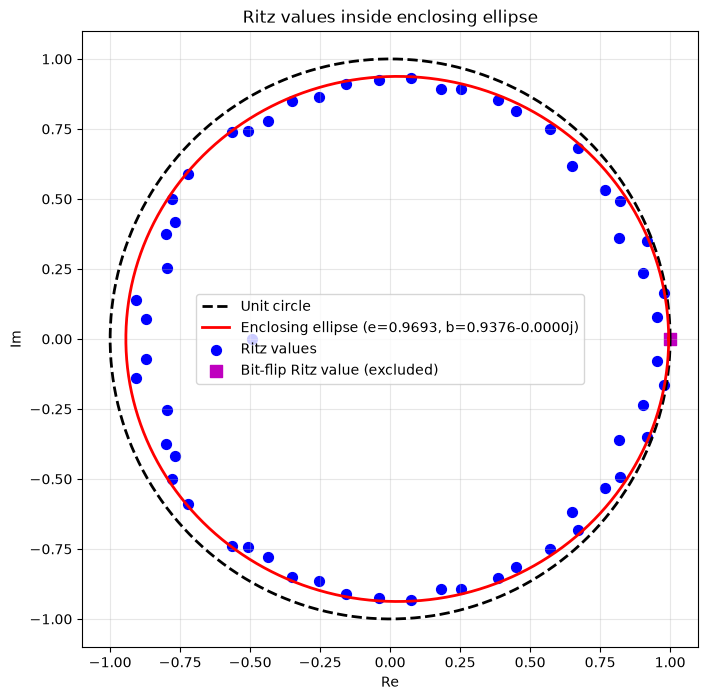

In [64]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [65]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 205.16ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 227.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 324.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 437.44ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 537.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 601.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 233.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 414.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 527.98ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 594.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 645.10ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 235.49ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 292.71ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 419.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 526.05ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 598.25ms ◆ 

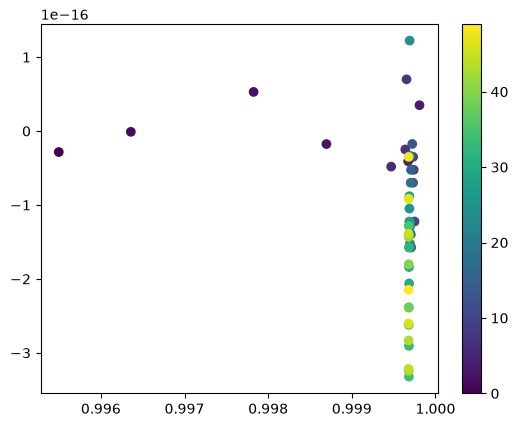

In [66]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

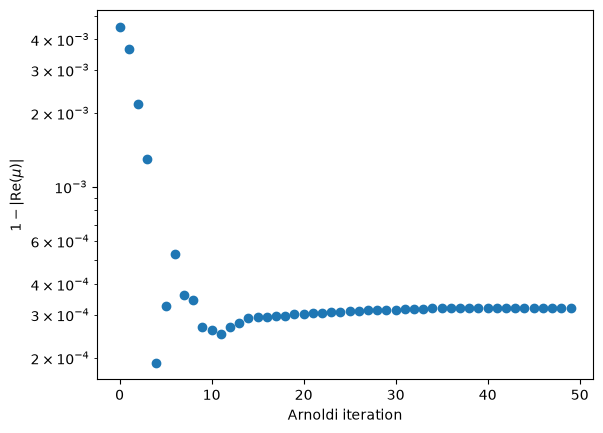

In [67]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [68]:
solver.rate_from_mu(mu_list[-1])

Array(0.00129502+8.66409388e-16j, dtype=complex128)

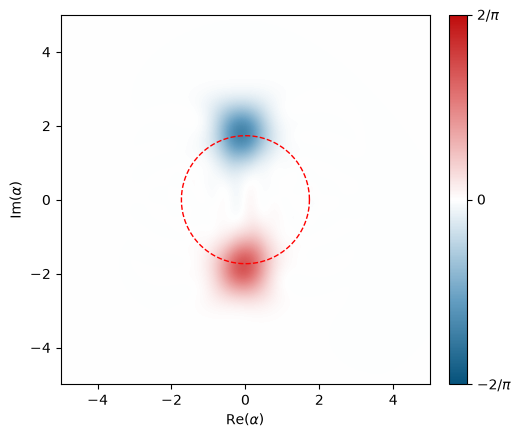

In [69]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [70]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 258.04ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99967882-1.26031885e-16j, dtype=complex128),
 'res_rel': Array(0.00033363, dtype=float64),
 'rate_RQ': Array(0.00129544+5.08423611e-16j, dtype=complex128)}

In [71]:
eps_p = .7
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 253.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 330.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 381.56ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 404.72ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 406.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 400.91ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 394.77ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 396.41ms ◆ remaining 0

In [72]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03854691340881011+6.069052042437592e-16j),
 'semi_re': np.float64(0.9556166728543875),
 'semi_im': np.complex128(0.943334829657091+3.6103782229561915e-16j),
 'ritz_bitflip': np.complex128(0.9991635862631976+8.914059539186442e-16j),
 'vertex_x': np.complex128(0.9941635862631976+8.914059539186442e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([ 0.29977425+9.02331540e-01j,  0.79649573+5.60192299e-01j,
         0.39573364+8.13469901e-01j,  0.53805293+7.55310691e-01j,
         0.65914232+6.87249180e-01j,  0.58853787+6.86453938e-01j,
         0.15361338+9.12623847e-01j, -0.0099178 +9.26631847e-01j,
         0.14376986+8.54287955e-01j,  0.7827923 +4.68700298e-01j,
         0.87214767+3.84324907e-01j,  0.86612006+3.44507005e-01j,
         0.97076588+1.87959055e-01j,  0.51847897+4.95672171e-01j,
         0.97076588-1.87959055e-01j,  0.86044882+9.21841844e-02j,
         0.91946306+2.64416745e-15j,  0.86044882-9.21841844e-02j,
     

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


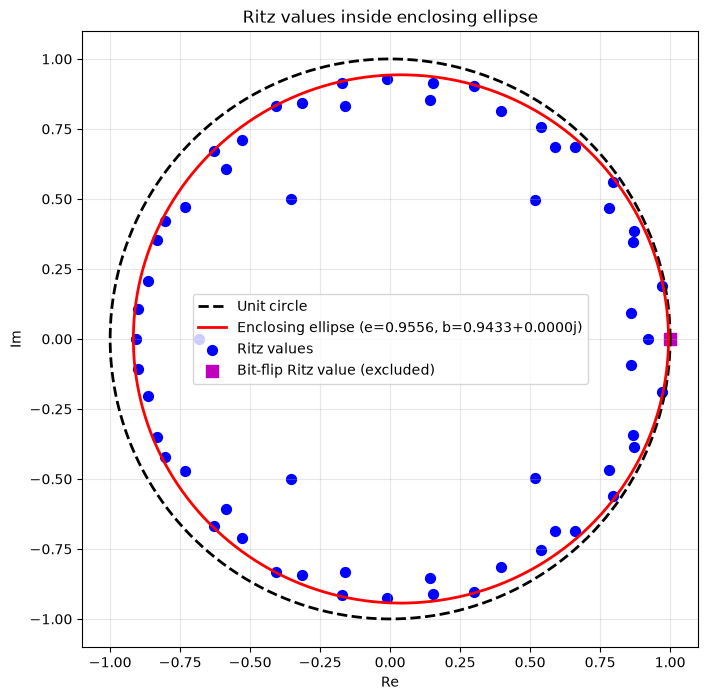

In [73]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [74]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 255.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.95ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 474.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 603.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 688.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 734.68ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 291.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 409.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 557.87ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 649.85ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 711.95ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 749.26ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 291.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 415.81ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 571.81ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 669.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 727.64ms ◆

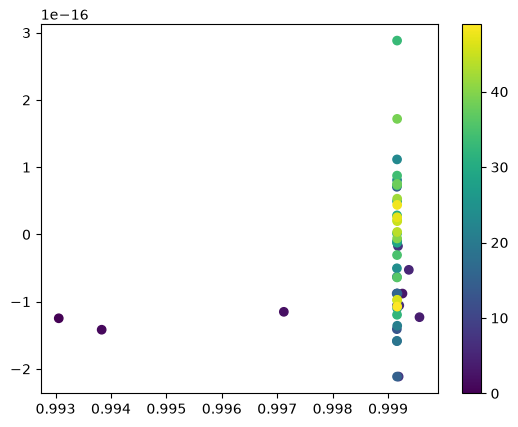

In [76]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

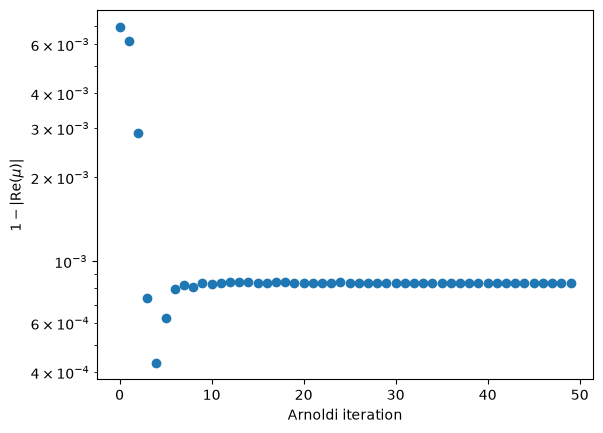

In [77]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [78]:
solver.rate_from_mu(mu_list[-1])

Array(0.00336985+4.3337101e-16j, dtype=complex128)

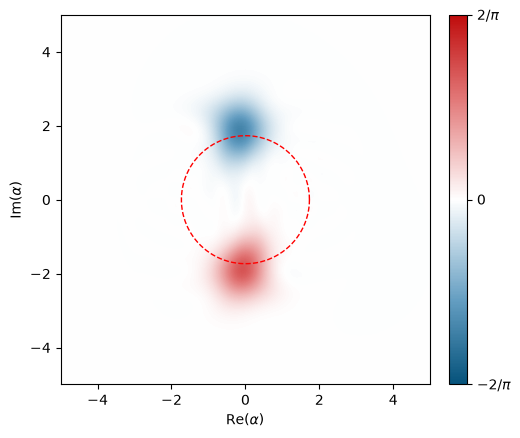

In [79]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [80]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 275.34ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99916379+3.02081913e-16j, dtype=complex128),
 'res_rel': Array(0.00087273, dtype=float64),
 'rate_RQ': Array(0.00337368-1.21925293e-15j, dtype=complex128)}

In [81]:
eps_p = .9
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
g = np.sin(eps_p) * E_J * phi_a**2 * phi_b
print(kappa_b / g)
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


0.5035178264225644


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 282.26ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 386.91ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.47ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 390.75ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 383.42ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 376.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 376.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 375.65ms ◆ remaining 0

In [82]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.027751626193110113+1.542477344646338e-16j),
 'semi_re': np.float64(0.9659535841171023),
 'semi_im': np.complex128(0.9418877767171078+2.4756841873963208e-17j),
 'ritz_bitflip': np.complex128(0.9987052103102124+2.277261604097511e-16j),
 'vertex_x': np.complex128(0.9937052103102124+2.277261604097511e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000002,
 'ritz_vals_enc': array([-0.65657806-6.60265023e-01j, -0.44637378-8.08710223e-01j,
        -0.55208638-7.18097291e-01j, -0.28658405-8.65840262e-01j,
        -0.12640139-9.27428159e-01j, -0.30993416-7.83148914e-01j,
        -0.12854453-8.45778096e-01j,  0.03473375-9.15220064e-01j,
         0.14193533-8.60908958e-01j,  0.27036953-8.84289175e-01j,
         0.40857169-8.48840909e-01j,  0.57551205-7.72051771e-01j,
         0.36010533-7.78839888e-01j,  0.59476491-6.81700578e-01j,
         0.73357182-5.84026223e-01j,  0.76723146-5.02532016e-01j,
         0.62350363-4.97576454e-01j,  0.89719384-3.61890709e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


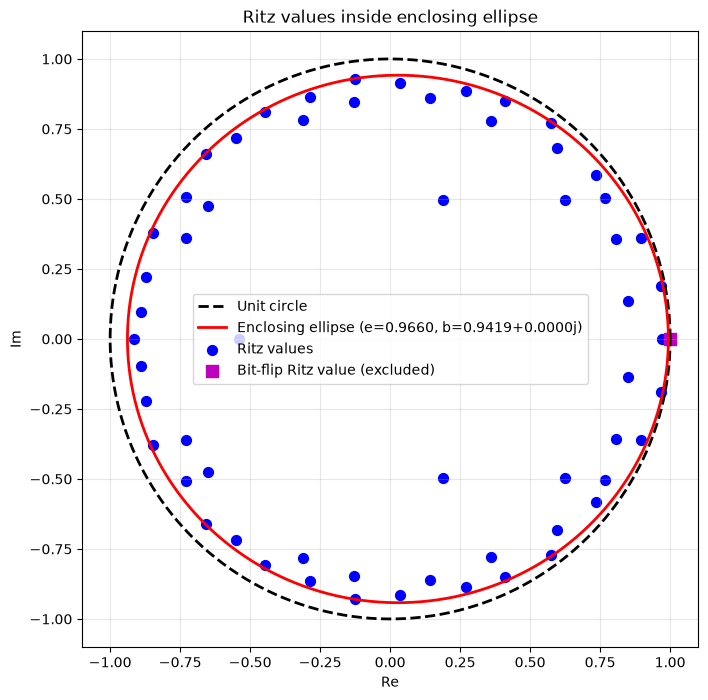

In [83]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [84]:
m_arnoldi = 30
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 281.49ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 329.03ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 477.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 595.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 660.56ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 709.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 300.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 409.39ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 553.25ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 641.20ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 700.36ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 735.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 295.62ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 391.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 525.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 608.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 666.17ms ◆

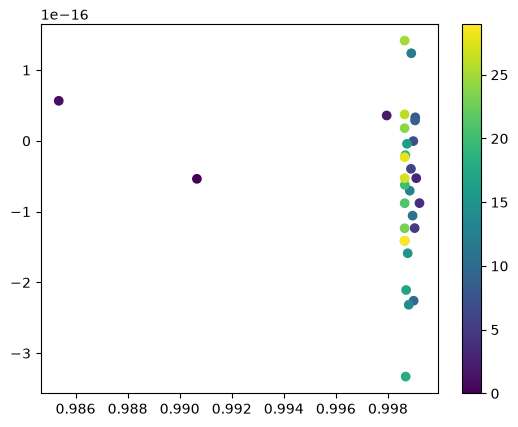

In [85]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

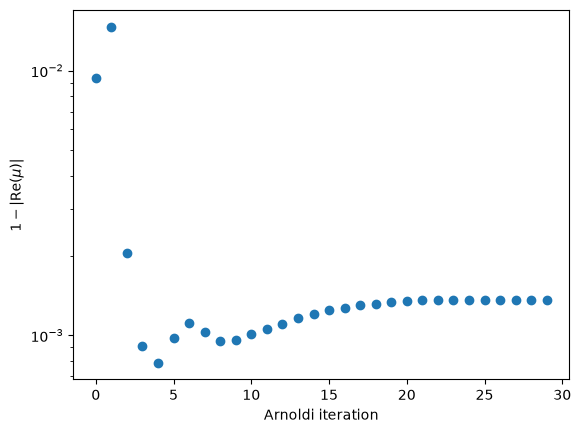

In [86]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [87]:
solver.rate_from_mu(mu_list[-1])

Array(0.00547965+5.70187913e-16j, dtype=complex128)

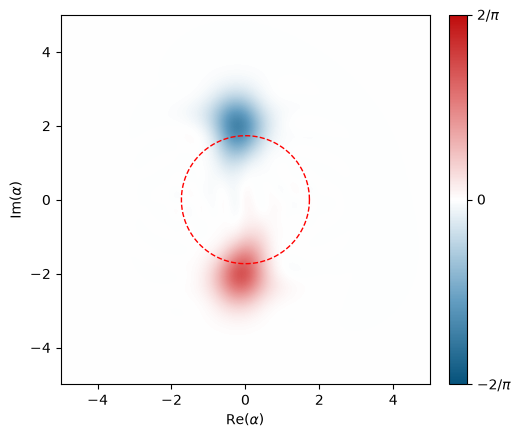

In [88]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [89]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 257.52ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99864211-9.42885313e-17j, dtype=complex128),
 'res_rel': Array(0.00065692, dtype=float64),
 'rate_RQ': Array(0.00547982+3.80763025e-16j, dtype=complex128)}

In [90]:
eps_p = 1.1
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 274.52ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 338.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 341.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 338.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 336.06ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 327.66ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 340.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 337.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 338.66ms ◆ remaining 0

In [91]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03225495849947402-1.0358429263890072e-16j),
 'semi_re': np.float64(0.9592612565524031),
 'semi_im': np.complex128(0.9503507663064731+3.4457654715196635e-17j),
 'ritz_bitflip': np.complex128(0.9965162150518772-1.5247790941469996e-16j),
 'vertex_x': np.complex128(0.9915162150518771-1.5247790941469996e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([ 0.88751226+3.52286766e-01j,  0.95808163+1.73217493e-01j,
         0.95808163-1.73217493e-01j,  0.94683507-3.45994517e-15j,
         0.88900906+1.64346485e-01j,  0.88751226-3.52286766e-01j,
         0.88900906-1.64346485e-01j,  0.77996042+1.31521310e-14j,
         0.76817712-3.67814814e-01j,  0.75331895-4.75736529e-01j,
         0.62164161-6.96316683e-01j,  0.63765416-5.45683772e-01j,
         0.47428683-7.74904906e-01j,  0.52229206-6.64707776e-01j,
         0.3231235 -9.03111680e-01j,  0.22539975-8.73769285e-01j,
         0.15621281-9.21264701e-01j,  0.39498667-5.56074142e-01j,
 

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


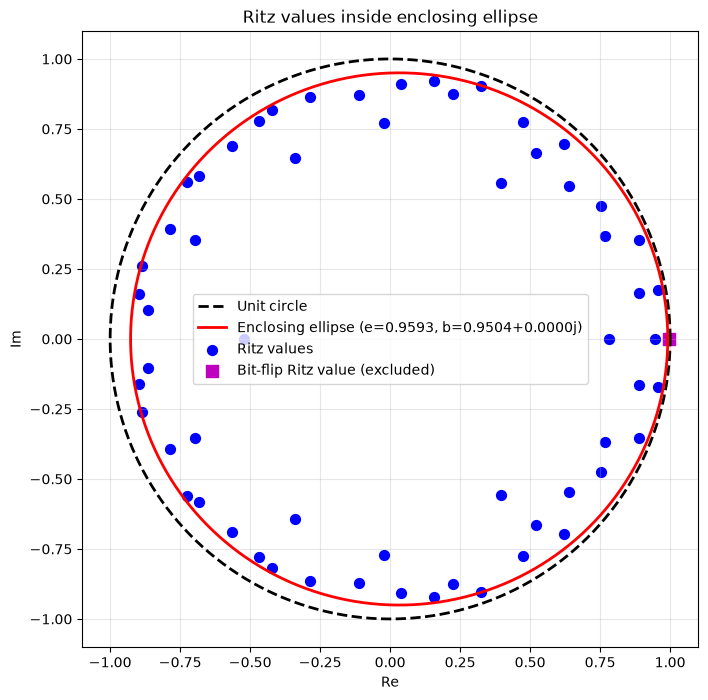

In [92]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [93]:
m_arnoldi = 40
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 230.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 341.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 503.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 596.40ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 641.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 657.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 284.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.46ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 551.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 629.44ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 672.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 691.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 274.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 397.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 530.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 600.86ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 651.58ms ◆

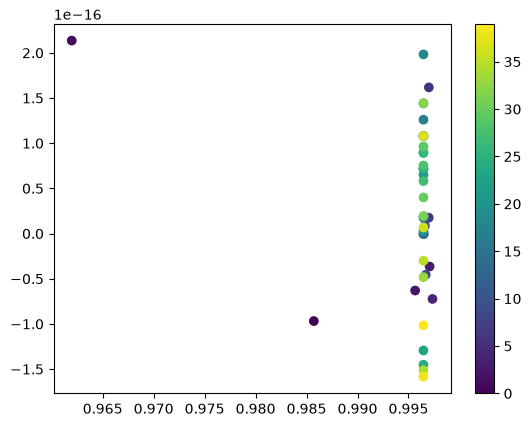

In [94]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

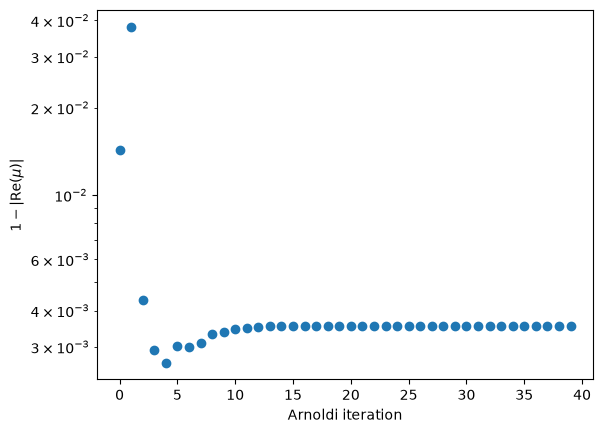

In [95]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [96]:
solver.rate_from_mu(mu_list[-1])

Array(0.01426072+4.11099988e-16j, dtype=complex128)

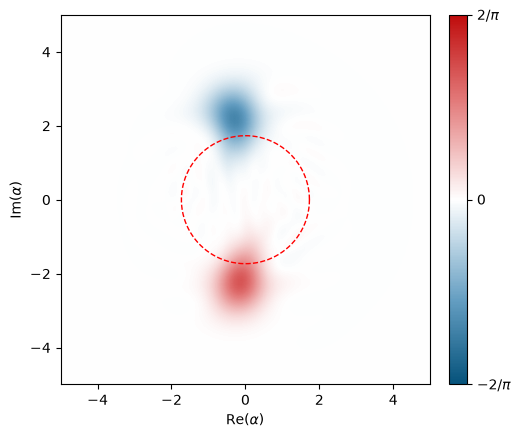

In [97]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [98]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 257.90ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99646996+3.18378218e-16j, dtype=complex128),
 'res_rel': Array(6.43954431e-05, dtype=float64),
 'rate_RQ': Array(0.0142611-1.28850144e-15j, dtype=complex128)}

In [99]:
eps_p = 1.3
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 257.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 291.71ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 287.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 290.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 291.55ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 295.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 294.15ms ◆ remaining 0

In [100]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.030795325125398954+1.5303657908198508e-16j),
 'semi_re': np.float64(0.9476061553776627),
 'semi_im': np.complex128(0.9477075519054315-1.690754121911082e-17j),
 'ritz_bitflip': np.complex128(0.9834014805030616+2.244461640388028e-16j),
 'vertex_x': np.complex128(0.9784014805030616+2.244461640388028e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999998,
 'ritz_vals_enc': array([-0.6455944 +6.47724421e-01j, -0.57455856+7.05319960e-01j,
        -0.35132546+8.34015374e-01j, -0.42722508+7.68054181e-01j,
         0.13371772+9.39714621e-01j, -0.03399839+9.23493771e-01j,
        -0.20479828+8.41103168e-01j, -0.10000506+8.34565931e-01j,
         0.1307402 +8.74392613e-01j, -0.75206979+5.06661940e-01j,
        -0.8479585 +3.39986508e-01j, -0.64155794+4.98498049e-01j,
        -0.53843487+4.81668726e-01j, -0.86474208+1.90727976e-01j,
        -0.91128007+5.25178226e-02j, -0.91128007-5.25178226e-02j,
        -0.68633883+2.28630642e-01j, -0.86474208-1.90727976e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


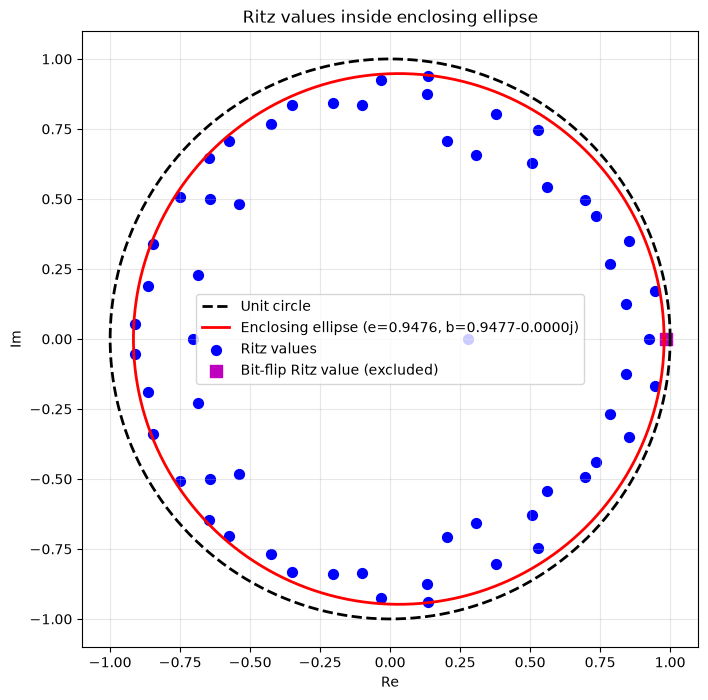

In [101]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [102]:
m_arnoldi = 40
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 248.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 458.03ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 595.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 635.73ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 626.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 620.52ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 283.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 503.22ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 618.21ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 665.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 669.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 663.10ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 276.79ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 511.75ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 626.89ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 629.63ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 641.47ms ◆

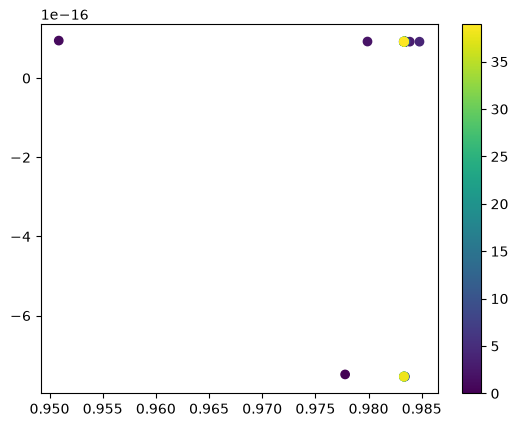

In [108]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

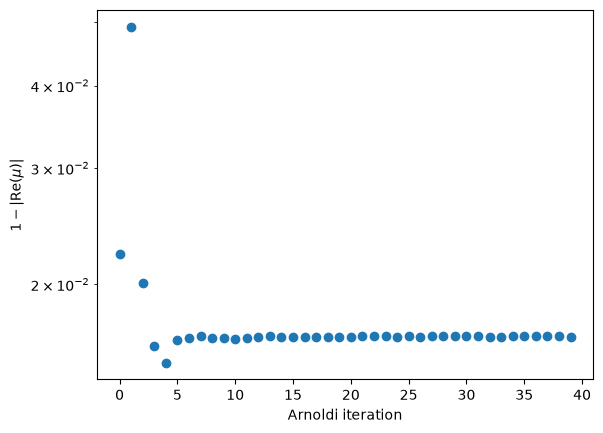

In [109]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [110]:
solver.rate_from_mu(mu_list[-1])

Array(0.06778042-3.77852123e-16j, dtype=complex128)

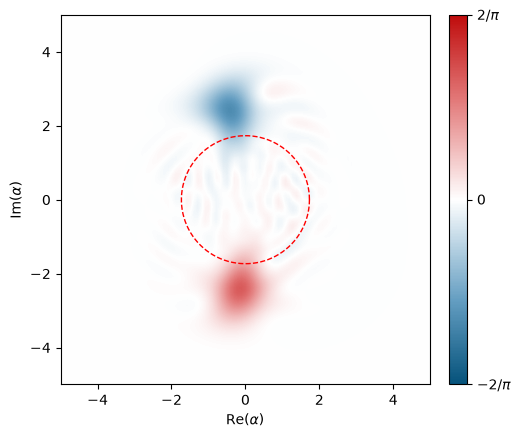

In [111]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [112]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 302.59ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.98333279+1.38158909e-16j, dtype=complex128),
 'res_rel': Array(0.00028179, dtype=float64),
 'rate_RQ': Array(0.06778185-5.66609885e-16j, dtype=complex128)}

In [114]:
tsave = jnp.linspace(0,T_block,100)
result = dq.mesolve(
    Ham_full, jump_ops, rho_ritz, tsave, assume_hermitian=False,
)

|██████████| 100.0% ◆ elapsed 54.93ms ◆ remaining 0.00ms


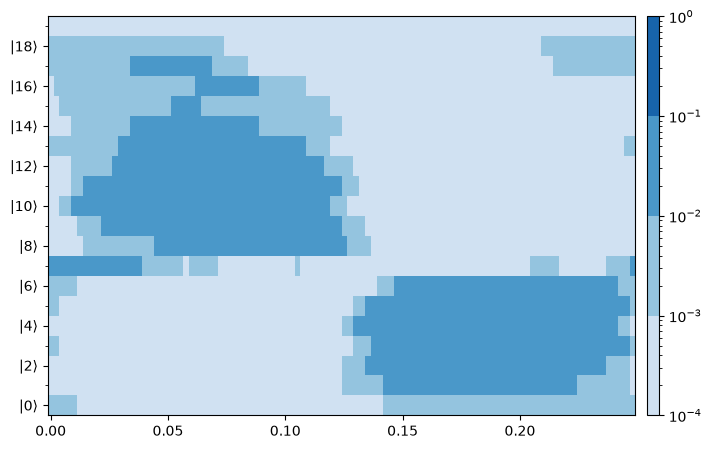

In [118]:

dq.plot.fock_evolution(dq.ptrace(result.states,0), times=tsave, logscale=True)